In [1]:
import sys
sys.path.append('../../')
from qufold import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, cd_ansatz
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_aer import AerSimulator
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [2]:
# Some utility functions for the problem

def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""
    # Define the interaction
    side_chains = [""] * len(main_seq)

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)

    penalty_back = 10
    penalty_chiral = 10
    penalty_1 = 10

    penalty_terms = PenaltyParameters(penalty_chiral, penalty_back, penalty_1)

    peptide = Peptide(main_seq, side_chains)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem


def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy


def classify_amino_acids(sequence):
    hydrophobic = set('GAVLIPFMW')
    return ''.join('H' if amino in hydrophobic else 'P' for amino in sequence)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}


In [3]:
# Set the protein sequence, select the energy potentials and construct the problem hamiltonian qubit_op
main_chain = "LHPGAGK"
pf = build_pf(main_chain, "mj_matrix")
qubit_op = pf.qubit_op()

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RYGate
import random
from qufold import yz_gate



def add_single_rot(quantum_circuit, pauli_list):
    theta_param = ParameterVector('theta', length=len(pauli_list[0]))  # One parameter per qubit
    # Apply H and RY gates to each qubit
    for i in range(len(pauli_list[0])):
        quantum_circuit.h(i)
        quantum_circuit.ry(theta_param[i], i)

def add_rzy_gates(quantum_circuit, pauli_list):
    # Filter strings to include only those with 2 or fewer 'Z's
    filtered_strings = [s for s in pauli_list if s.count('Z') <= 2]
    # Calculate the total count of Z pairs across all filtered strings, only pairs
    z_locality = sum((s.count('Z') // 2) * 2 for s in filtered_strings)
    phi_param = ParameterVector('phi', length=z_locality)
    param_index = 0
    
    def process_string(pauli_list):
        nonlocal param_index
        z_indices = [i for i, char in enumerate(pauli_list) if char == 'Z']
        if len(z_indices) % 2 == 1:
            z_indices.remove(random.choice(z_indices))
        for i in range(0, len(z_indices), 2):
            rzy_gate = yz_gate.RZYGate(phi_param[param_index])
            quantum_circuit.append(rzy_gate, [z_indices[i], z_indices[i+1]])
            param_index += 1

    for term in filtered_strings:
        process_string(term)

def create_dcd_ansatz(qubit_op):
    qc = QuantumCircuit(qubit_op.num_qubits)
    z_terms = []
    for term in qubit_op.paulis:
        z_terms.append(term.to_label())
    # First apply single qubit rotations
    add_single_rot(qc, z_terms)
    # Then add RZY gates based on Z indices to the filtered list
    add_rzy_gates(qc, z_terms)
    return qc


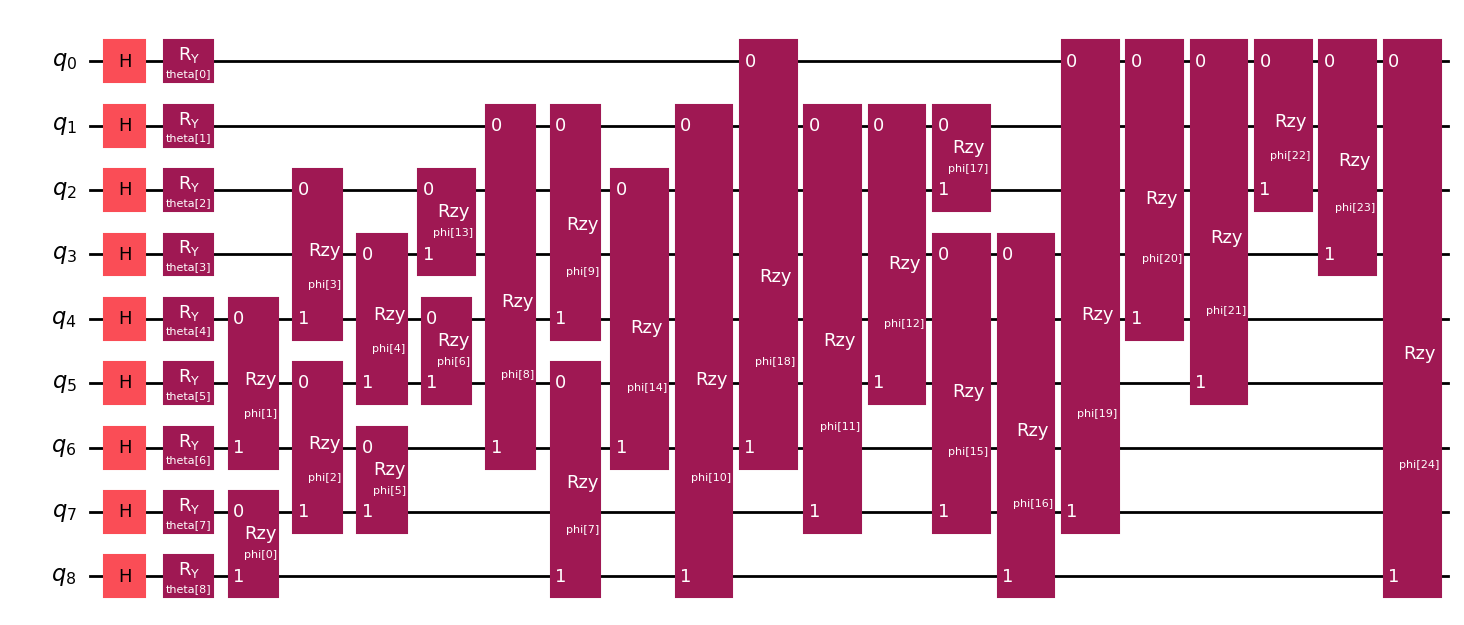

In [7]:
circuit = create_dcd_ansatz(qubit_op)

circuit.draw('mpl', fold=-1)

In [4]:
def run_vqe_estimator(hamiltonian):
    hamiltonian = qubit_op #problem hamiltonian
    ansatz = cd_ansatz.create_dcd_ansatz(hamiltonian) #choose your ansatz
    num_params = ansatz.num_parameters

    aer_sim = AerSimulator(method='matrix_product_state') #to run locally
    # To run on hardware, select the backend with the fewest number of jobs in the queue
    #service = QiskitRuntimeService(channel="ibm_quantum")
    #backend = service.least_busy(operational=True, simulator=False)
    pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=3) #pass manager setup

    ansatz_isa = pm.run(ansatz) #transpile the circuit for the backend
    hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout) #apply layout to the hamiltonian as well
    

    x0 = 2 * np.pi * np.random.random(num_params)
    # x0 =  [np.pi/2] * num_params #select a random starting vector

    # Start the session with an estimator and find the minimum eigenvalue

    with Session(backend=aer_sim) as session:
        estimator = Estimator(session=session)
        estimator.options.default_shots = 5000

        res = minimize(
            cost_func,
            x0,
            args=(ansatz_isa, hamiltonian_isa, estimator),
            method="cobyla"
        )

    # options= {'maxiter':500}
    # all(cost_history_dict["prev_vector"] == res.x)
    # cost_history_dict["iters"] == res.nfev

    # Plot the cost function over vqe
    fig, ax = plt.subplots()
    ax.plot(range(cost_history_dict["iters"]), cost_history_dict["cost_history"])
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Cost")
    plt.draw()

    # Solution is found, bind the optimal parameters to the ansatz
    ansatz_bind = ansatz.assign_parameters(res.x)
    ansatz_bind.measure_all()
    pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=3)
    isa_ansatz_bind_meas = pm.run(ansatz_bind)
    # Now with the optimal parameters, rerun the ansatz to get the most likely solution bitstring
    with Session(backend=aer_sim) as session:
        sampler = Sampler(session=session)
        result = sampler.run([isa_ansatz_bind_meas]).result()
    counts = result[0].data.meas.get_counts()

    solution_bitstring = max(counts, key=counts.get)
    final_result = pf.interpret_bitstring(solution_bitstring)

    return final_result

c:\Users\8J6010897\AppData\Local\anaconda3\envs\new\Lib\site-packages\qiskit_ibm_runtime\session.py:157: UserWarning: Session is not supported in local testing mode or when using a simulator.
  warnings.warn(
c:\Users\8J6010897\AppData\Local\anaconda3\envs\new\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:243: UserWarning: Options {'default_shots': 5000} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


Iters. done: 1 [Current cost: 1399.2454279785156]
Iters. done: 2 [Current cost: 1388.9868740234376]
Iters. done: 3 [Current cost: 1426.154671875]
Iters. done: 4 [Current cost: 1549.364512207031]
Iters. done: 5 [Current cost: 1265.2235852050783]
Iters. done: 6 [Current cost: 1288.149848388672]
Iters. done: 7 [Current cost: 1220.18011328125]
Iters. done: 8 [Current cost: 1298.995050292969]
Iters. done: 9 [Current cost: 1353.020061767578]
Iters. done: 10 [Current cost: 1405.0604382324218]
Iters. done: 11 [Current cost: 1430.6725354003906]
Iters. done: 12 [Current cost: 1427.5044089355467]
Iters. done: 13 [Current cost: 1484.8478793945312]
Iters. done: 14 [Current cost: 1109.8360192871094]
Iters. done: 15 [Current cost: 1217.7104414062499]
Iters. done: 16 [Current cost: 991.1265119628906]
Iters. done: 17 [Current cost: 1423.138020263672]
Iters. done: 18 [Current cost: 1013.0624206542968]
Iters. done: 19 [Current cost: 1032.5876025390626]
Iters. done: 20 [Current cost: 1091.5573891601562]
I

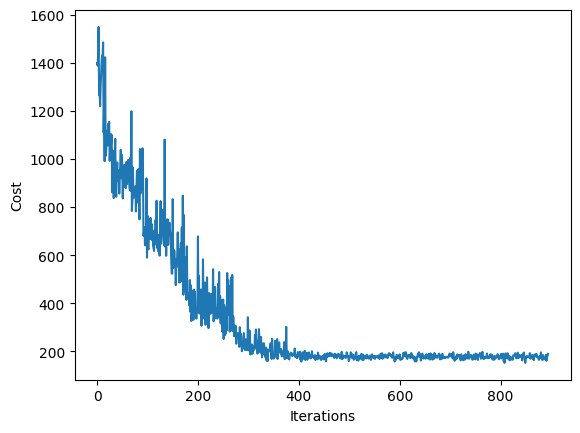

In [5]:
solution = run_vqe_estimator(qubit_op)

[['L' '0.0' '0.0' '0.0']
 ['H' '2.193931022920578' '2.193931022920578' '-2.193931022920578']
 ['P' '4.387862045841156' '0.0' '-4.387862045841156']
 ['G' '6.581793068761733' '-2.193931022920578' '-2.193931022920578']
 ['A' '4.387862045841155' '-4.387862045841156' '0.0']
 ['G' '2.193931022920577' '-2.193931022920578' '2.193931022920578']
 ['K' '-8.881784197001252e-16' '-4.387862045841156' '4.387862045841156']]


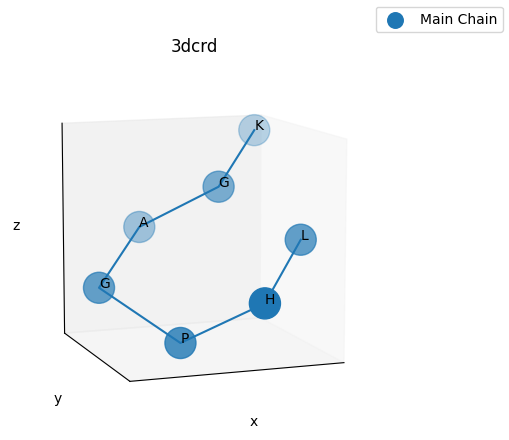

In [6]:
xyz_coords = solution.protein_shape_file_gen.get_xyz_data()
print(xyz_coords)
fig = solution.get_figure(title="3dcrd", ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)
plt.show()

In [ ]:
solution.save_xyz_file(replace=True)